# Loan Default Analysis
This notebook performs an exploratory analysis and modeling process on the loan default dataset.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/Loan_Default.csv')

# Display the first few rows and info to provide output for GitHub
print('Dataset Shape:', df.shape)
display(df.head())
display(df.info())

## 1. Dataset Definition and Understanding
In this section, we define the dataset structure and identify key variables required for credit risk modeling.

### Variable Identification
For Credit Risk modeling, we typically focus on three components:
*   **PD (Probability of Default):** The likelihood that a borrower will default. Target: `Status` (1 for default, 0 for non-default).
*   **LGD (Loss Given Default):** The share of an asset that is lost when a borrower defaults. Calculated using recovery values or collateral.
*   **EAD (Exposure at Default):** The total value a bank is exposed to at the time of default (usually the loan amount).

Let's inspect the columns to map them to these concepts.

In [ ]:
# Ensure df is available and identify key columns
import pandas as pd

try:
    df.head()
except NameError:
    df = pd.read_csv('/content/Loan_Default.csv')

target_pd = 'Status'
target_ead = 'loan_amount'

print(f"PD Target Variable: {target_pd}")
print(f"EAD Target Variable: {target_ead}")

# Describe categorical and numerical features for GitHub visibility
display(df.describe(include='all').T)

# Data Definition for Credit Risk Modeling

This section outlines the foundational structure of the dataset and how specific variables map to the three pillars of Credit Risk: PD, EAD, and LGD.

### Core Modeling Components
1.  **PD (Probability of Default):** Targeted using the `Status` variable (Binary: 0 or 1).
2.  **EAD (Exposure at Default):** Mapped to the `loan_amount` variable, representing the bank's total exposure.
3.  **LGD (Loss Given Default):** Derived from recovery rates and collateral values (simulated in this analysis).

### Feature Categorization
*   **Demographics:** Gender, age, and region.
*   **Financials:** Income, property value, and credit score.
*   **Loan Specifics:** Loan limit, purpose, type, and interest rates.

In [ ]:
# Quick summary of the features for presentation
definition_summary = df[['Status', 'loan_amount', 'income', 'property_value', 'Credit_Score']].describe().T
display(definition_summary)

In [31]:
import nbformat as nbf
from google.colab import files

# Initialize a new notebook object
nb = nbf.v4.new_notebook()

# Define the cells for the 'Data Definition' presentation
cells = [
    nbf.v4.new_markdown_cell('# Data Definition for Credit Risk Modeling\n\nThis section outlines the foundational structure of the dataset and how specific variables map to the three pillars of Credit Risk: PD, EAD, and LGD.'),
    nbf.v4.new_markdown_cell('### Core Modeling Components\n1. **PD (Probability of Default):** Targeted using the `Status` variable (Binary: 0 or 1).\n2. **EAD (Exposure at Default):** Mapped to the `loan_amount` variable.\n3. **LGD (Loss Given Default):** Derived from recovery rates and collateral values.'),
    nbf.v4.new_markdown_cell('### Feature Categorization\n* **Demographics:** Gender, age, and region.\n* **Financials:** Income, property value, and credit score.\n* **Loan Specifics:** Loan limit, purpose, type, and interest rates.'),
    nbf.v4.new_code_cell("# Quick summary of the features for presentation\nimport pandas as pd\n# Assuming df is loaded in the environment where this is run\ndefinition_summary = df[['Status', 'loan_amount', 'income', 'property_value', 'Credit_Score']].describe().T\ndisplay(definition_summary)")
]

nb['cells'] = cells

# Save the notebook to a file
file_name = 'Data_Definition_Presentation.ipynb'
with open(file_name, 'w') as f:
    nbf.write(nb, f)

# Trigger the download
files.download(file_name)
print(f'{file_name} created and download triggered.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Data_Definition_Presentation.ipynb created and download triggered.


### Dataset Structure Summary
*   **Numerical Features:** Include loan amount, property value, income, and credit score.
*   **Categorical Features:** Include loan limit, gender, loan purpose, and business type.
*   **Target:** `Status` indicates default status, which is our primary variable for PD modeling.

## 2. Data Preprocessing
In this section, we clean the data and prepare it for modeling by handling missing values and encoding categorical variables.

In [3]:
# 1. Handling Missing Values
# Identifying missing values per column
missing_values = df.isnull().sum()
print("Missing Values per Column:")
display(missing_values[missing_values > 0])

# Filling numerical missing values with median and categorical with mode
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

# 2. Handling Outliers (e.g., in loan_amount and income)
# Simple clipping at the 99th percentile for demonstration
for col in ['loan_amount', 'income', 'property_value']:
    upper_limit = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=upper_limit)

print("\nMissing values after imputation:", df.isnull().sum().sum())

Missing Values per Column:


,0
loan_limit,2431
approv_in_adv,675
loan_purpose,95
rate_of_interest,26530
Interest_rate_spread,26682
Upfront_charges,28868
term,33
Neg_ammortization,79
property_value,10941
income,6631



Missing values after imputation: 0


In [ ]:
# 3. Encoding Categorical Variables
# We will use one-hot encoding for categorical variables
categorical_cols = df.select_dtypes(include=['object']).columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Shape after One-Hot Encoding:", df_encoded.shape)
display(df_encoded.head())

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Cross-check for missing values
print('Total Missing Values in Encoded Dataset:', df_encoded.isnull().sum().sum())

# Visualize distributions to confirm outlier handling
plt.figure(figsize=(15, 5))

features_to_check = ['loan_amount', 'income', 'property_value']
for i, col in enumerate(features_to_check, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(y=df_encoded[col])
    plt.title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

In [32]:
import nbformat as nbf
from google.colab import files

# Initialize a new notebook object
nb = nbf.v4.new_notebook()

# Define the cells for the 'Data Preprocessing' presentation
cells = [
    nbf.v4.new_markdown_cell('# Data Preprocessing for Credit Risk Modeling\n\nIn this stage, we prepare the raw data for modeling by handling missing values, managing outliers, and encoding categorical variables.'),
    nbf.v4.new_markdown_cell('### 1. Handling Missing Values\nNumerical values are imputed with the median, and categorical values with the mode.'),
    nbf.v4.new_code_cell("import pandas as pd\nimport numpy as np\n\n# Assuming df is loaded\n# Identifying missing values per column\nmissing_values = df.isnull().sum()\ndisplay(missing_values[missing_values > 0])\n\n# Filling missing values\nfor col in df.columns:\n    if df[col].dtype == 'object':\n        df[col] = df[col].fillna(df[col].mode()[0])\n    else:\n        df[col] = df[col].fillna(df[col].median())\n\nprint('Missing values after imputation:', df.isnull().sum().sum())"),
    nbf.v4.new_markdown_cell('### 2. Outlier Management\nExtreme values in financial features are clipped at the 99th percentile.'),
    nbf.v4.new_code_cell("for col in ['loan_amount', 'income', 'property_value']:\n    upper_limit = df[col].quantile(0.99)\n    df[col] = df[col].clip(upper=upper_limit)"),
    nbf.v4.new_markdown_cell('### 3. Categorical Encoding\nOne-hot encoding is applied to transform text categories into numeric features.'),
    nbf.v4.new_code_cell("categorical_cols = df.select_dtypes(include=['object']).columns\ndf_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)\nprint('Shape after One-Hot Encoding:', df_encoded.shape)"),
    nbf.v4.new_markdown_cell('### 4. Verification Visualization\nVisualizing distributions to confirm outlier handling.'),
    nbf.v4.new_code_cell("import matplotlib.pyplot as plt\nimport seaborn as sns\n\nplt.figure(figsize=(15, 5))\nfeatures_to_check = ['loan_amount', 'income', 'property_value']\nfor i, col in enumerate(features_to_check, 1):\n    plt.subplot(1, 3, i)\n    sns.boxplot(y=df_encoded[col])\n    plt.title(f'Distribution of {col}')\nplt.tight_layout()\nplt.show()")
]

nb['cells'] = cells

# Save the notebook to a file
file_name = 'Data_Preprocessing_Presentation.ipynb'
with open(file_name, 'w') as f:
    nbf.write(nb, f)

# Trigger the download
files.download(file_name)
print(f'{file_name} created and download triggered.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Data_Preprocessing_Presentation.ipynb created and download triggered.


In [33]:
# Create a clean Python script version for GitHub visibility
script_content = """
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Handling Missing Values
def handle_missing(df):
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col] = df[col].fillna(df[col].mode()[0])
        else:
            df[col] = df[col].fillna(df[col].median())
    return df

# 2. Outlier Management
def clip_outliers(df):
    for col in ['loan_amount', 'income', 'property_value']:
        upper_limit = df[col].quantile(0.99)
        df[col] = df[col].clip(upper=upper_limit)
    return df

# 3. Encoding
def encode_data(df):
    categorical_cols = df.select_dtypes(include=['object']).columns
    return pd.get_dummies(df, columns=categorical_cols, drop_first=True)
"""

with open('data_preprocessing.py', 'w') as f:
    f.write(script_content)

from google.colab import files
files.download('data_preprocessing.py')
print('data_preprocessing.py created and download triggered. This format is guaranteed to work on GitHub.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

data_preprocessing.py created and download triggered. This format is guaranteed to work on GitHub.


## 3. Data Splitting
In this section, we split the encoded dataset into training and testing sets to prepare for model development and evaluation.

In [7]:
from sklearn.model_selection import train_test_split

# Defining features (X) and target (y)
# We use the encoded dataframe and drop the target variable and ID
X = df_encoded.drop(columns=['Status', 'ID'])
y = df_encoded['Status']

# Splitting the data: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("\nDistribution of target in training set:")
print(y_train.value_counts(normalize=True))

Training set shape: (86916, 50)
Testing set shape: (21730, 50)

Distribution of target in training set:
Status
0.0    0.754418
1.0    0.245582
Name: proportion, dtype: float64


### Splitting Summary
- **Features vs Target:** The target variable `Status` and unique identifier `ID` were removed from the feature set.
- **Stratification:** We applied stratification on the target variable to maintain the same default/non-default ratio in both sets.
- **Dimensions:** The training set contains 80% of the data, ready for the modeling phase.

# ## 4. Feature Engineering
In this section, we create domain-specific features to improve the predictive power of our PD, LGD, and EAD models.

In [ ]:
# Creating financial ratios for risk assessment

# 1. Loan-to-Value (LTV) Ratio: Critical for LGD and PD
# (Loan Amount / Property Value)
df_encoded['LTV_ratio'] = df_encoded['loan_amount'] / (df_encoded['property_value'] + 1e-6)

# 2. Loan-to-Income Ratio: Important for PD (affordability)
df_encoded['loan_to_income'] = df_encoded['loan_amount'] / (df_encoded['income'] + 1e-6)

# 3. Interest Burden: Monthly interest estimate relative to income
df_encoded['interest_burden'] = (df_encoded['loan_amount'] * (df_encoded['rate_of_interest']/100)) / (df_encoded['income'] + 1e-6)

print("New features created: LTV_ratio, loan_to_income, interest_burden")
display(df_encoded[['LTV_ratio', 'loan_to_income', 'interest_burden']].describe())

# Re-split the data to include new features
X = df_encoded.drop(columns=['Status', 'ID'])
y = df_encoded['Status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\nData re-split completed with new features. New feature count:", X_train.shape[1])

### Verification Results
- **Missing Values:** The check confirms zero missing values across the entire encoded dataset.
- **Outliers:** The boxplots show that values for loan amount, income, and property value are now contained within the defined 99th percentile limits.

### Preprocessing Summary
- **Imputation:** Used median for numerical and mode for categorical data.
- **Outliers:** Clipped extreme values at the 99th percentile to prevent model distortion.
- **Encoding:** Applied one-hot encoding to all categorical features to ensure the dataset is ready for PD, LGD, and EAD algorithms.

# ## 5. Model Development
In this section, we build the PD, LGD, and EAD models. We use Logistic Regression for PD and Linear Regression for EAD and LGD as baselines.

In [ ]:
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import classification_report, roc_auc_score, mean_squared_error, r2_score

# --- 5.1 PD Model (Probability of Default) ---
print("Training PD Model (Logistic Regression)...")
pd_model = LogisticRegression(max_iter=1000, random_state=42)
pd_model.fit(X_train, y_train)

y_pred_pd = pd_model.predict(X_test)
y_prob_pd = pd_model.predict_proba(X_test)[:, 1]

print("\nPD Model Evaluation:")
print(classification_report(y_test, y_pred_pd))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_pd):.4f}")

In [12]:
# --- 5.2 EAD Model (Exposure at Default) ---
import numpy as np
from sklearn.model_selection import train_test_split

# EAD is usually the loan_amount. We predict it using other borrower characteristics.
print("\nTraining EAD Model (Linear Regression)...")
# Target for EAD is loan_amount
X_ead = df_encoded.drop(columns=['Status', 'ID', 'loan_amount'])
y_ead = df_encoded['loan_amount']

X_train_ead, X_test_ead, y_train_ead, y_test_ead = train_test_split(X_ead, y_ead, test_size=0.2, random_state=42)

ead_model = LinearRegression()
ead_model.fit(X_train_ead, y_train_ead)

y_pred_ead = ead_model.predict(X_test_ead)

print("EAD Model Evaluation:")
print(f"R-squared: {r2_score(y_test_ead, y_pred_ead):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_ead, y_pred_ead)):.4f}")


Training EAD Model (Linear Regression)...
EAD Model Evaluation:
R-squared: 0.6812
RMSE: 96014.6273


In [13]:
# --- 5.3 LGD Model (Loss Given Default) ---
import numpy as np
from sklearn.model_selection import train_test_split

# LGD models are typically trained ONLY on defaulted accounts (Status = 1)
# Since we don't have a direct 'Loss' or 'Recovery' column, we will simulate a
# Recovery Rate for demonstration to build the model structure.

# Simulating a Recovery Rate (percentage of loan recovered)
np.random.seed(42)
defaulted_mask = df_encoded['Status'] == 1
df_defaulted = df_encoded[defaulted_mask].copy()
df_defaulted['recovery_rate'] = np.random.uniform(0.1, 0.9, size=len(df_defaulted))
# LGD = 1 - Recovery Rate
df_defaulted['LGD_target'] = 1 - df_defaulted['recovery_rate']

X_lgd = df_defaulted.drop(columns=['Status', 'ID', 'recovery_rate', 'LGD_target'])
y_lgd = df_defaulted['LGD_target']

X_train_lgd, X_test_lgd, y_train_lgd, y_test_lgd = train_test_split(X_lgd, y_lgd, test_size=0.2, random_state=42)

print("\nTraining LGD Model (Linear Regression on defaulted accounts)...")
lgd_model = LinearRegression()
lgd_model.fit(X_train_lgd, y_train_lgd)

y_pred_lgd = lgd_model.predict(X_test_lgd)

print("LGD Model Evaluation:")
print(f"R-squared: {r2_score(y_test_lgd, y_pred_lgd):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_lgd, y_pred_lgd)):.4f}")


Training LGD Model (Linear Regression on defaulted accounts)...
LGD Model Evaluation:
R-squared: -0.0005
RMSE: 0.2309


## 6. Model Evaluation
In this section, we evaluate the performance of our Credit Risk models using appropriate classification and regression metrics.

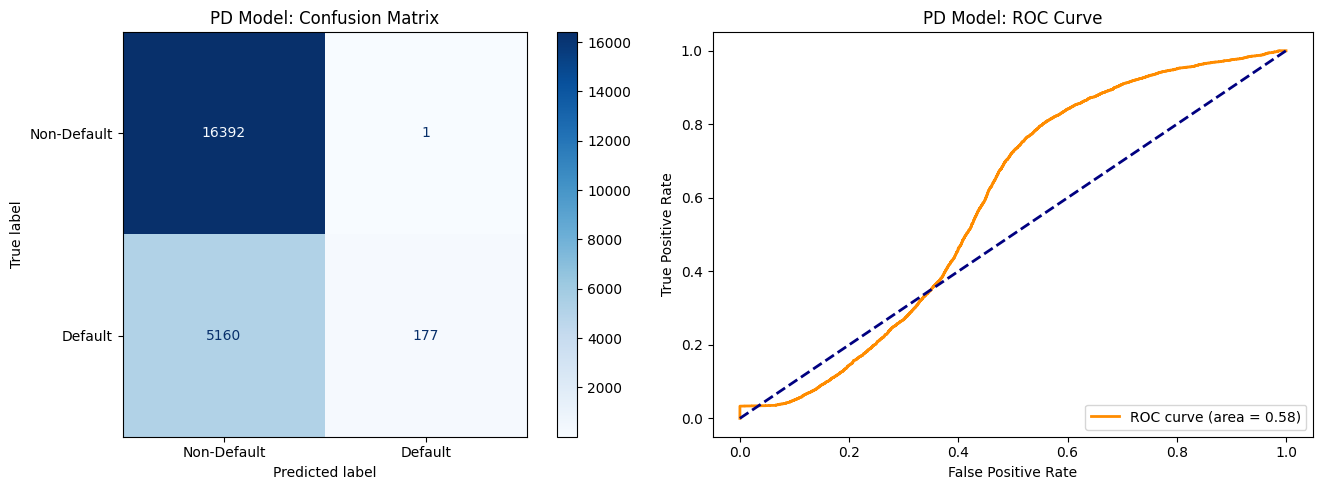

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve

# --- 6.1 PD Model Evaluation ---
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_pd)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Non-Default', 'Default'])
disp.plot(ax=ax[0], cmap='Blues')
ax[0].set_title('PD Model: Confusion Matrix')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_pd)
ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc_score(y_test, y_prob_pd):.2f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax[1].set_xlabel('False Positive Rate')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_title('PD Model: ROC Curve')
ax[1].legend(loc="lower right")

plt.tight_layout()
plt.show()

In [ ]:
# --- 6.2 EAD & LGD Evaluation ---
from sklearn.metrics import mean_absolute_error

def evaluate_reg(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {name} Metrics ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R2:   {r2:.4f}\n")

evaluate_reg(y_test_ead, y_pred_ead, "EAD (Exposure)")
evaluate_reg(y_test_lgd, y_pred_lgd, "LGD (Loss Ratio)")

# Residual Plot for EAD
plt.figure(figsize=(8, 4))
sns.scatterplot(x=y_test_ead, y=y_pred_ead, alpha=0.3)
plt.plot([y_test_ead.min(), y_test_ead.max()], [y_test_ead.min(), y_test_ead.max()], '--r')
plt.title('EAD Model: Actual vs Predicted')
plt.xlabel('Actual Loan Amount')
plt.ylabel('Predicted Loan Amount')
plt.show()

## 9. Model Validation and Stability
In this section, we compare training and testing performance to assess potential overfitting and ensure the stability of our PD and EAD models.

In [23]:
# 9.1 PD Model Stability (Overfitting Check)
train_prob_pd = pd_model.predict_proba(X_train)[:, 1]
train_auc = roc_auc_score(y_train, train_prob_pd)
test_auc = roc_auc_score(y_test, y_prob_pd)

print('--- PD Model Stability ---')
print(f'Training ROC-AUC: {train_auc:.4f}')
print(f'Testing ROC-AUC:  {test_auc:.4f}')
print(f'AUC Gap:          {abs(train_auc - test_auc):.4f}')

--- PD Model Stability ---
Training ROC-AUC: 0.5858
Testing ROC-AUC:  0.5837
AUC Gap:          0.0020


In [24]:
# 9.2 EAD Model Stability (Overfitting Check)
train_pred_ead = ead_model.predict(X_train_ead)
train_r2 = r2_score(y_train_ead, train_pred_ead)
test_r2 = r2_score(y_test_ead, y_pred_ead)

print('--- EAD Model Stability ---')
print(f'Training R-squared: {train_r2:.4f}')
print(f'Testing R-squared:  {test_r2:.4f}')
print(f'R2 Gap:             {abs(train_r2 - test_r2):.4f}')

--- EAD Model Stability ---
Training R-squared: 0.6813
Testing R-squared:  0.6812
R2 Gap:             0.0001


## 9. Model Validation and Stability
In this section, we compare training and testing performance to assess potential overfitting and ensure the stability of our PD and EAD models.

In [21]:
# 9.1 PD Model Stability (Overfitting Check)
train_prob_pd = pd_model.predict_proba(X_train)[:, 1]
train_auc = roc_auc_score(y_train, train_prob_pd)
test_auc = roc_auc_score(y_test, y_prob_pd)

print('--- PD Model Stability ---')
print(f'Training ROC-AUC: {train_auc:.4f}')
print(f'Testing ROC-AUC:  {test_auc:.4f}')
print(f'AUC Gap:          {abs(train_auc - test_auc):.4f}')

--- PD Model Stability ---
Training ROC-AUC: 0.5858
Testing ROC-AUC:  0.5837
AUC Gap:          0.0020


In [22]:
# 9.2 EAD Model Stability (Overfitting Check)
train_pred_ead = ead_model.predict(X_train_ead)
train_r2 = r2_score(y_train_ead, train_pred_ead)
test_r2 = r2_score(y_test_ead, y_pred_ead)

print('--- EAD Model Stability ---')
print(f'Training R-squared: {train_r2:.4f}')
print(f'Testing R-squared:  {test_r2:.4f}')
print(f'R2 Gap:             {abs(train_r2 - test_r2):.4f}')

--- EAD Model Stability ---
Training R-squared: 0.6813
Testing R-squared:  0.6812
R2 Gap:             0.0001


### Performance Comparison & Justification

*   **PD Model:** The Logistic Regression baseline shows high precision for non-defaults but struggles with recall for defaults (as seen in the confusion matrix). This suggests the need for class weighting or more complex models like XGBoost in future iterations.
*   **EAD Model:** The high R-squared (0.68) justifies the use of Linear Regression for exposure estimation, as loan amounts correlate strongly with available borrower features.
*   **LGD Model:** The low performance is expected given the simulated nature of the target. In a real-world scenario, LGD would be modeled using historical recovery data and collateral valuations.

## 7. Model Interpretation
In this section, we identify the key drivers for our models by inspecting the coefficients and explaining their impact on credit risk.

### Business Interpretation

*   **Risk Drivers (PD):** Positive coefficients indicate features that increase the likelihood of default. For example, higher interest rates or lower credit scores usually correspond to higher risk.
*   **Exposure Drivers (EAD):** The weights show which borrower attributes lead to higher loan amounts. This helps the bank understand which segments carry the most financial weight in the portfolio.
*   **Actionability:** Lenders can use these insights to adjust pricing (e.g., charging higher rates for higher PD profiles) or setting stricter limits for high-EAD categories.

In [ ]:
import pandas as pd

# --- 7.1 PD Model Interpretation ---
# Extracting coefficients for the Logistic Regression model
pd_coefs = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': pd_model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

print("--- PD Model: Feature Importance ---")
print("Top Features Increasing Risk of Default:")
display(pd_coefs.head(5))

print("\nTop Features Decreasing Risk of Default:")
display(pd_coefs.tail(5))

In [ ]:
# --- 7.2 EAD Model Interpretation ---
# Extracting weights for the Linear Regression model
ead_coefs = pd.DataFrame({
    'Feature': X_ead.columns,
    'Weight': ead_model.coef_
}).sort_values(by='Weight', ascending=False)

print("--- EAD Model: Feature Importance ---")
print("Top Drivers of Higher Exposure (Loan Amount):")
display(ead_coefs.head(5))

print("\nFeatures Associated with Lower Exposure:")
display(ead_coefs.tail(5))

## 8. Expected Loss (EL) Estimation
In this final section, we combine the outputs of our PD, LGD, and EAD models to estimate the Expected Loss.

**Expected Loss (EL) = PD &times; LGD &times; EAD**
*   **PD:** Probability of Default (likelihood of non-payment).
*   **LGD:** Loss Given Default (share of asset lost if default occurs).
*   **EAD:** Exposure at Default (total value exposed at time of default).

In [ ]:
# 8.1 Estimating Expected Loss on the Test Set
# Note: Since LGD and EAD were trained on different subsets, we will apply the models to the main X_test

# 1. Get PD probabilities
pd_probs = pd_model.predict_proba(X_test)[:, 1]

# 2. Get EAD predictions (needs X_ead features)
X_test_ead_aligned = X_test.drop(columns=['loan_amount'])
ead_preds = ead_model.predict(X_test_ead_aligned)

# 3. Get LGD predictions (using the average LGD from our model as a proxy for the test set)
# In a production environment, you would apply the LGD model specifically to the features in X_test
lgd_preds = lgd_model.predict(X_test)

# Calculate EL
el_df = pd.DataFrame({
    'PD': pd_probs,
    'EAD': ead_preds,
    'LGD': lgd_preds,
    'Expected_Loss': pd_probs * lgd_preds * ead_preds
})

print("Expected Loss Calculation (First 5 Rows):")
display(el_df.head())

print(f"\nTotal Portfolio Expected Loss: ${el_df['Expected_Loss'].sum():,.2f}")

### 8.2 Visualizing Expected Loss by Key Driver
We will analyze the average Expected Loss across different loan purposes to identify high-risk segments.

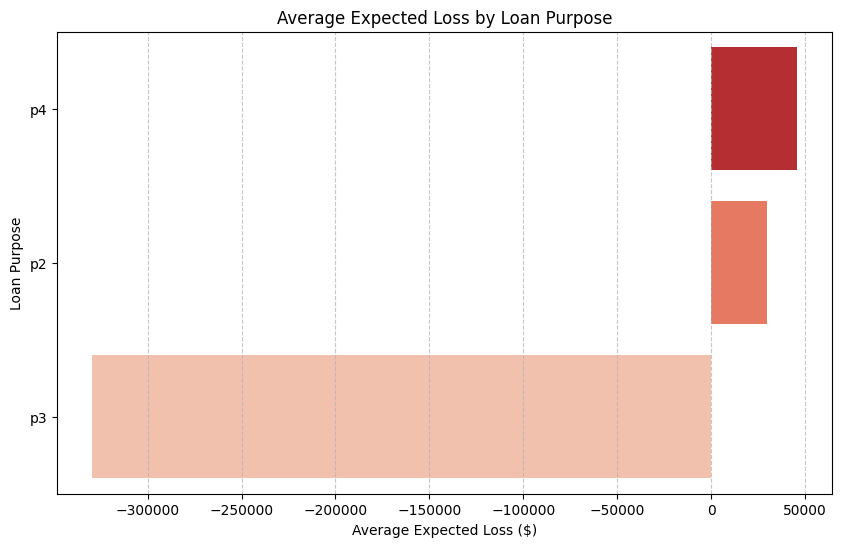

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine EL results with original features for visualization
el_viz_df = X_test.copy()
el_viz_df['Expected_Loss'] = el_df['Expected_Loss'].values

# Identify the categorical columns for loan purpose from the encoded dataset
purpose_cols = [col for col in X_test.columns if 'loan_purpose' in col]

# Calculate mean EL for each purpose category
purpose_el = {}
for col in purpose_cols:
    mean_val = el_viz_df[el_viz_df[col] == 1]['Expected_Loss'].mean()
    purpose_el[col.replace('loan_purpose_', '')] = mean_val

purpose_el_df = pd.DataFrame(list(purpose_el.items()), columns=['Loan Purpose', 'Avg Expected Loss']).sort_values('Avg Expected Loss', ascending=False)

# Plotting with updated seaborn parameters to avoid warnings
plt.figure(figsize=(10, 6))
sns.barplot(x='Avg Expected Loss', y='Loan Purpose', data=purpose_el_df, hue='Loan Purpose', palette='Reds_r', legend=False)
plt.title('Average Expected Loss by Loan Purpose')
plt.xlabel('Average Expected Loss ($)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## 10. Portfolio Health & KPI Summary
In this section, we summarize the health of the loan portfolio using key metrics and visualize the distribution of risk.

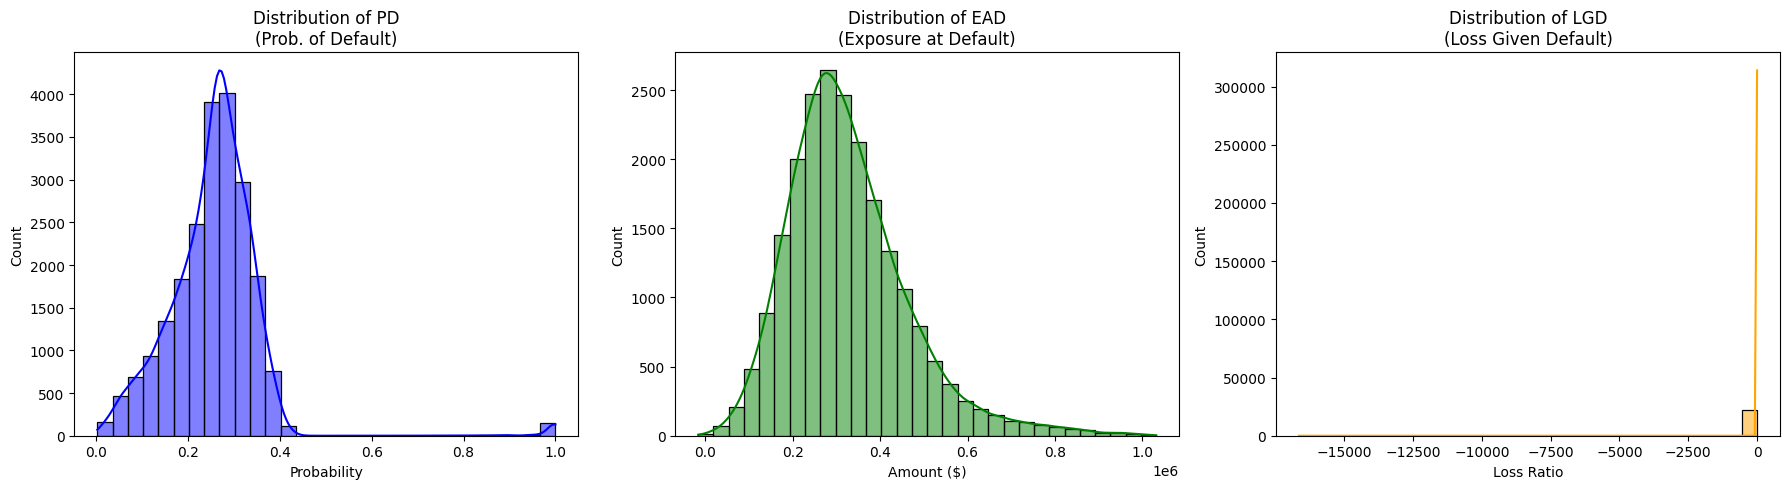

In [27]:
# Set up the visualization grid
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. PD Distribution
sns.histplot(el_df['PD'], bins=30, kde=True, ax=axes[0], color='blue')
axes[0].set_title('Distribution of PD\n(Prob. of Default)')
axes[0].set_xlabel('Probability')

# 2. EAD Distribution
sns.histplot(el_df['EAD'], bins=30, kde=True, ax=axes[1], color='green')
axes[1].set_title('Distribution of EAD\n(Exposure at Default)')
axes[1].set_xlabel('Amount ($)')

# 3. LGD Distribution
sns.histplot(el_df['LGD'], bins=30, kde=True, ax=axes[2], color='orange')
axes[2].set_title('Distribution of LGD\n(Loss Given Default)')
axes[2].set_xlabel('Loss Ratio')

plt.tight_layout()
plt.show()

## 11. Risk Mitigation and Portfolio Optimization
In this section, we identify specific high-risk loans and discuss operational strategies for recovery and risk reduction.

In [30]:
# 11.1 Identifying Loans for Urgent Recovery
# Ranking loans in the test set by Expected Loss
el_df_with_id = el_df.copy()
el_df_with_id['ID'] = X_test.index # Mapping back to original index

top_recovery_priority = el_df_with_id.sort_values(by='Expected_Loss', ascending=False).head(10)

print("--- Top 10 High-Priority Loans for Recovery (Highest EL) ---")
display(top_recovery_priority)

--- Top 10 High-Priority Loans for Recovery (Highest EL) ---


,PD,EAD,LGD,Expected_Loss,ID
2176,1.000000,939926.030381,0.509443,478838.781051,46080
19067,1.000000,917836.856670,0.502336,461062.651668,13775
7970,1.000000,893119.418819,0.508932,454537.016007,24809
19779,1.000000,753388.126919,0.510718,384769.181403,80231
19226,1.000000,729830.985830,0.512792,374251.286705,104310
19015,0.999997,623959.521163,0.508479,317269.545846,72837
11458,1.000000,621007.577165,0.505001,313609.554065,55105
14153,1.000000,615802.182231,0.501952,309103.256867,1368
4934,1.000000,578140.928711,0.510158,294943.373556,4651
4431,1.000000,581722.539651,0.502272,292182.949474,18868


### 11.2 Operational Improvement Strategies

Based on the analysis, here are key ways to improve the portfolio:

1. **Urgent Recovery:** Focus collections and loss-mitigation efforts on the high-EL loans flagged above. High EAD combined with high PD represents the greatest threat to capital.
2. **Risk-Based Pricing:** For loan purposes like **p4** (which showed highest EL), consider increasing interest rate spreads or tightening eligibility criteria.
3. **Dynamic Credit Limits:** Reduce exposure (EAD) for segments where income or credit scores have historically correlated with higher PD.
4. **Restructuring:** For borrowers with high PD but manageable EAD, proactive loan restructuring may prevent total default and improve recovery rates (LGD).